In [1]:
!pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
csv_file = '/home/jovyan/data/classified_packets.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f"Loaded {len(df)} classified events")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("No classified events found!")

Loaded 100 classified events
Dataset shape: (100, 16)
Columns: ['event_id', 'timestamp', 'event_type', 'source_ip', 'dest_ip', 'source_port', 'dest_port', 'protocol', 'bytes_sent', 'bytes_received', 'classification', 'severity', 'mitre_tactic', 'mitre_technique', 'description', 'classified_at']


In [4]:
# Display first few rows
print("Sample Events:")
df.head(10)

Sample Events:


,event_id,timestamp,event_type,source_ip,dest_ip,source_port,dest_port,protocol,bytes_sent,bytes_received,classification,severity,mitre_tactic,mitre_technique,description,classified_at
0,f6ed42b3-4598-496b-9aa6-849dd6fc1371,2026-02-03T11:53:40.255484,normal_web,134.113.228.56,62.177.133.34,35841,80,TCP,34331,2861,benign,none,NaN,NaN,Normal Web Traffic,2026-02-03T12:05:48.022058
1,62303159-1f88-4b81-8b2a-c303b8435de6,2026-02-03T11:53:40.864302,data_exfil,4.72.24.95,9.14.218.92,21015,22,TCP,55759,39319,malicious,critical,Exfiltration,T1048,Data Exfiltration,2026-02-03T12:05:48.022186
2,211d198b-2de9-49f9-9d1e-59e987247f6f,2026-02-03T11:53:41.069574,normal_web,150.194.208.243,194.254.231.84,18026,443,TCP,15511,33622,benign,none,NaN,NaN,Normal Web Traffic,2026-02-03T12:05:48.022261
3,9437ae52-a073-40b4-b6be-b3b17cb940fc,2026-02-03T11:53:41.876320,data_exfil,51.108.115.168,212.75.25.27,11917,21,UDP,87777,14132,malicious,critical,Exfiltration,T1048,Data Exfiltration,2026-02-03T12:05:48.022320
4,c0cea2e9-da45-463b-ad89-7ac272b83967,2026-02-03T11:53:42.286847,normal_web,45.28.206.75,184.10.67.129,33571,80,TCP,36245,77513,benign,none,NaN,NaN,Normal Web Traffic,2026-02-03T12:05:48.022394
5,36b0e71f-f285-49ba-8117-afd8b4d3d1d7,2026-02-03T11:53:42.895819,port_scan,168.108.247.96,177.108.176.122,51532,443,TCP,9353,7745,suspicious,medium,Discovery,T1046,Network Service Scanning,2026-02-03T12:05:48.022463
6,f5545311-44e0-42cf-be27-58f5f8f5f7d6,2026-02-03T11:53:43.100778,port_scan,184.21.185.131,236.185.207.96,4886,22,TCP,60440,17808,suspicious,medium,Discovery,T1046,Network Service Scanning,2026-02-03T12:05:48.022515
7,9b648fd7-d1fc-4c14-ab20-82a72c344112,2026-02-03T11:53:43.405736,brute_force,119.60.123.248,101.204.119.242,5591,3389,TCP,45987,75606,malicious,high,Credential Access,T1110,Brute Force Attack,2026-02-03T12:05:48.022572
8,bed6a03d-ef05-4460-9935-e9d3797250af,2026-02-03T11:53:43.508356,dns_query,229.83.148.141,62.175.218.120,43603,53,UDP,26797,25841,benign,none,NaN,NaN,DNS Query,2026-02-03T12:05:48.023613
9,93d5b705-e405-4764-b362-2b7a938e43ce,2026-02-03T11:53:44.124286,dns_query,195.76.128.86,15.78.149.51,12164,53,UDP,78649,3341,benign,none,NaN,NaN,DNS Query,2026-02-03T12:05:48.023871


In [5]:
# Basic Statistics
print("CLASSIFICATION DISTRIBUTION")
print("=" * 50)
print(df['classification'].value_counts())
print(f"\nTotal Events: {len(df)}")
print(f"Benign: {len(df[df['classification'] == 'benign'])} ({len(df[df['classification'] == 'benign'])/len(df)*100:.1f}%)")
print(f"Suspicious: {len(df[df['classification'] == 'suspicious'])} ({len(df[df['classification'] == 'suspicious'])/len(df)*100:.1f}%)")
print(f"Malicious: {len(df[df['classification'] == 'malicious'])} ({len(df[df['classification'] == 'malicious'])/len(df)*100:.1f}%)")

CLASSIFICATION DISTRIBUTION
classification
malicious     45
benign        38
suspicious    17
Name: count, dtype: int64

Total Events: 100
Benign: 38 (38.0%)
Suspicious: 17 (17.0%)
Malicious: 45 (45.0%)


In [6]:
# MITRE ATT&CK Analysis
print("MITRE ATT&CK TACTICS")
print("=" * 50)
mitre_tactics = df[df['mitre_tactic'].notna()]['mitre_tactic'].value_counts()
print(mitre_tactics)

print("\nMITRE ATT&CK TECHNIQUES")
print("=" * 50)
mitre_techniques = df[df['mitre_technique'].notna()]['mitre_technique'].value_counts()
print(mitre_techniques)

MITRE ATT&CK TACTICS
mitre_tactic
Exfiltration         26
Credential Access    19
Discovery            17
Name: count, dtype: int64

MITRE ATT&CK TECHNIQUES
mitre_technique
T1048    26
T1110    19
T1046    17
Name: count, dtype: int64


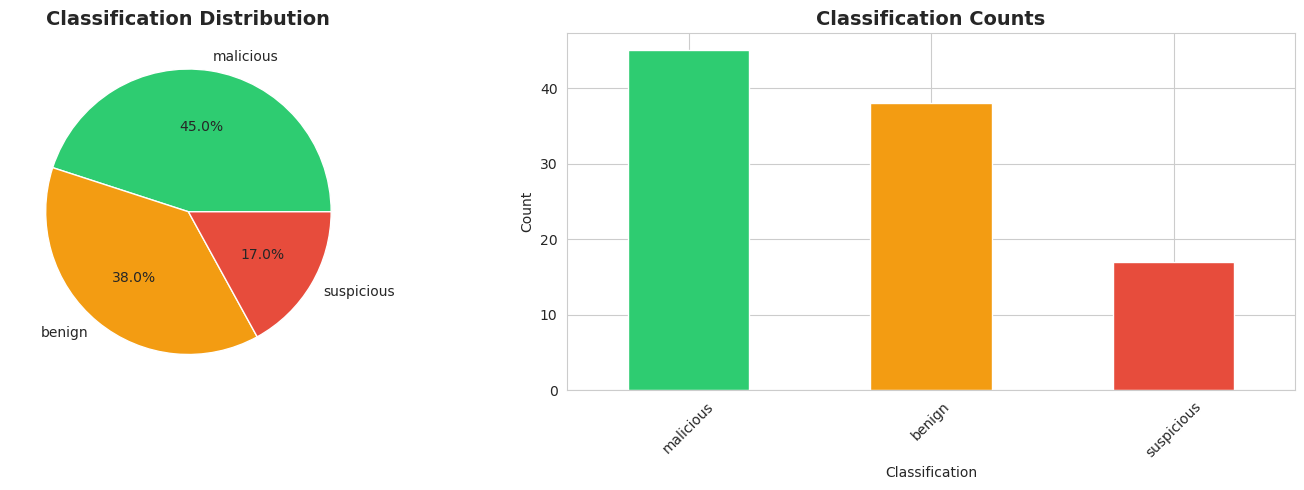

In [7]:
# Visualization 1: Classification Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
df['classification'].value_counts().plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[0].set_title('Classification Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar chart
df['classification'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[1].set_title('Classification Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Classification')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

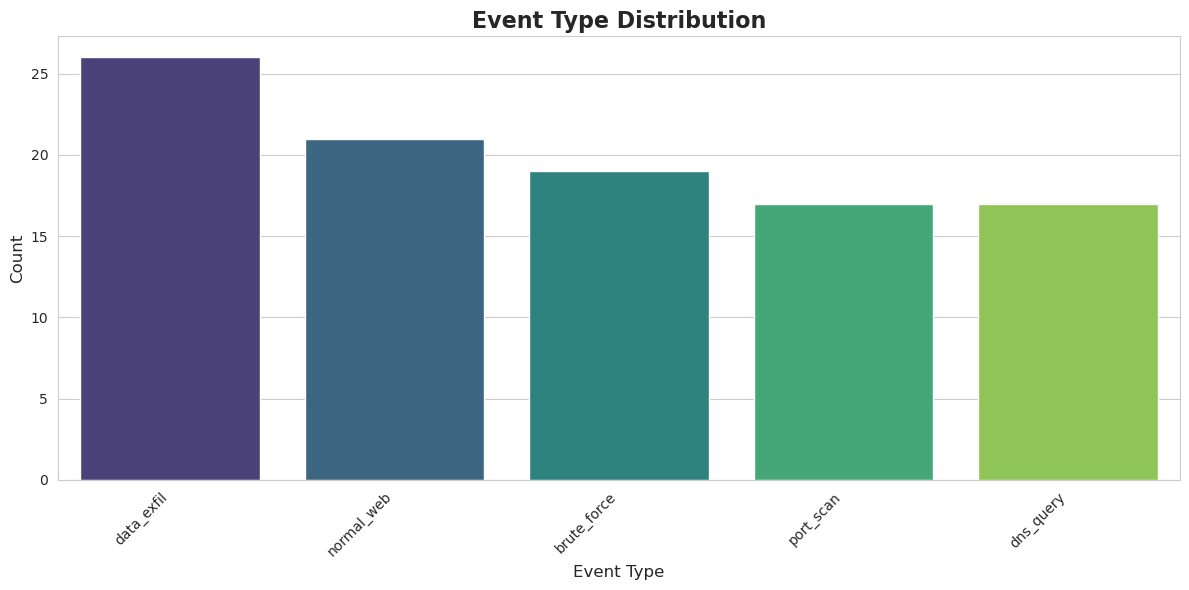

In [8]:
# Visualization 2: Event Types
plt.figure(figsize=(12, 6))
event_counts = df['event_type'].value_counts()
sns.barplot(x=event_counts.index, y=event_counts.values, hue=event_counts.index, palette='viridis', legend=False)
plt.title('Event Type Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Event Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

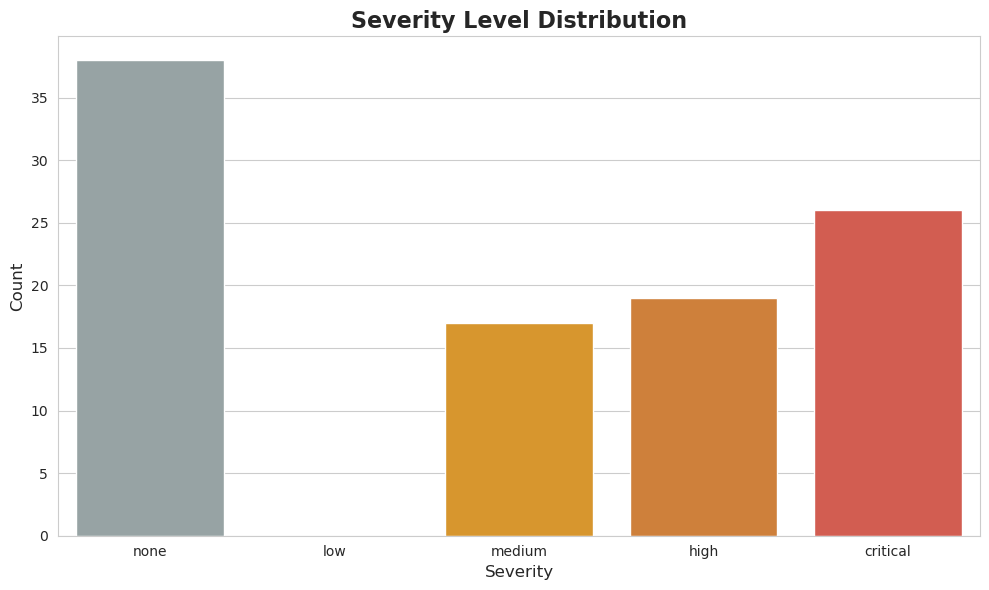

In [9]:
# Visualization 3: Severity Levels
plt.figure(figsize=(10, 6))
severity_order = ['none', 'low', 'medium', 'high', 'critical']
severity_counts = df['severity'].value_counts().reindex(severity_order, fill_value=0)
colors = ['#95a5a6', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
ax = sns.barplot(x=severity_counts.index, y=severity_counts.values, hue=severity_counts.index, palette=colors, legend=False)
plt.title('Severity Level Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Severity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

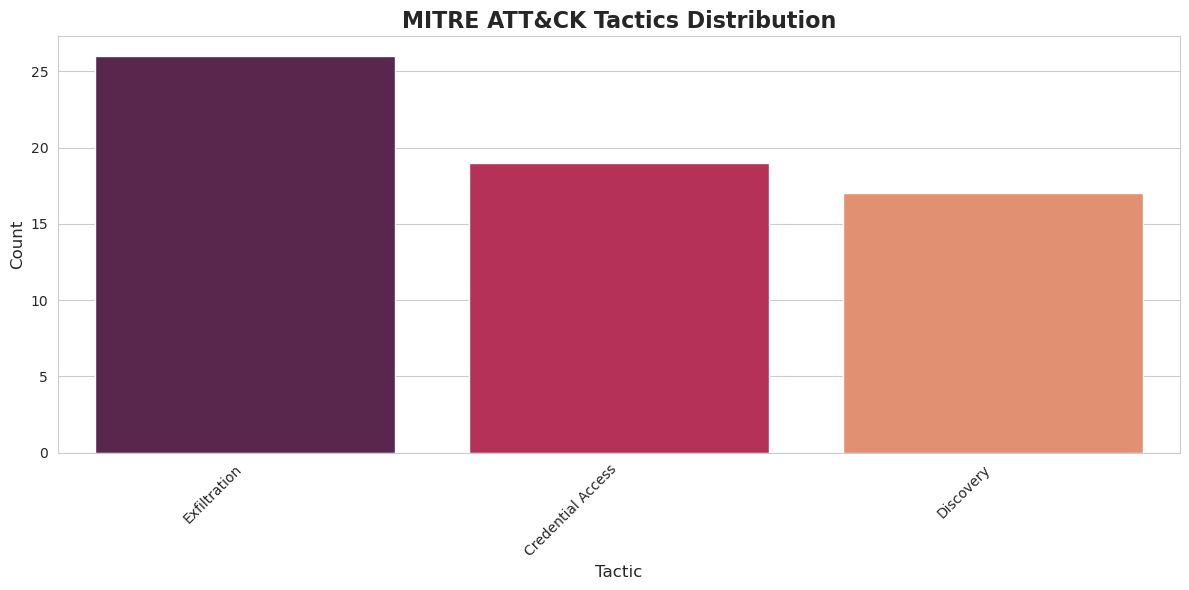

In [10]:
# Visualization 4: MITRE ATT&CK Tactics
if len(mitre_tactics) > 0:
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=mitre_tactics.index, y=mitre_tactics.values, hue=mitre_tactics.index, palette='rocket', legend=False)
    plt.title('MITRE ATT&CK Tactics Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Tactic', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No MITRE tactics detected in this dataset")